## Importing All Necessary Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

## Importing Datasets

In [ ]:
dataset_1 = pd.read_csv("emotion_dataset_raw.csv")
dataset_2 = pd.read_csv("combined_emotion.csv")

In [ ]:
print(dataset_1.shape)
print(dataset_2.shape)

(34792, 2)
(422746, 2)


In [ ]:
print("Dataset 1: ", dataset_1)
print("Dataset 2: ", dataset_2)

Dataset 1:          Emotion                                               Text
0       neutral                                             Why ? 
1           joy    Sage Act upgrade on my to do list for tommorow.
2       sadness  ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...
3           joy   Such an eye ! The true hazel eye-and so brill...
4           joy  @Iluvmiasantos ugh babe.. hugggzzz for u .!  b...
...         ...                                                ...
34787  surprise  @MichelGW have you gift! Hope you like it! It'...
34788       joy  The world didnt give it to me..so the world MO...
34789     anger                           A man robbed me today . 
34790      fear  Youu call it JEALOUSY, I call it of #Losing YO...
34791   sadness  I think about you baby, and I dream about you ...

[34792 rows x 2 columns]
Dataset 2:                                                   sentence emotion
0           i just feel really helpless and heavy hearted    fear
1       ive en

In [ ]:
print(len(dataset_1))
print(len(dataset_2))

34792
422746


In [ ]:
print(dataset_1.head(5000).to_string())

       Emotion                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            Text
0      neutral                                                                                                                                                                                                                                                                                                                                                                                                                                                           

## Imporitng Libraries to preprocess data

In [ ]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\moham\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\moham\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

## Dataset_1

In [ ]:
copy_d1 = dataset_1.copy()

In [ ]:
print(copy_d1)

        Emotion                                               Text
0       neutral                                             Why ? 
1           joy    Sage Act upgrade on my to do list for tommorow.
2       sadness  ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...
3           joy   Such an eye ! The true hazel eye-and so brill...
4           joy  @Iluvmiasantos ugh babe.. hugggzzz for u .!  b...
...         ...                                                ...
34787  surprise  @MichelGW have you gift! Hope you like it! It'...
34788       joy  The world didnt give it to me..so the world MO...
34789     anger                           A man robbed me today . 
34790      fear  Youu call it JEALOUSY, I call it of #Losing YO...
34791   sadness  I think about you baby, and I dream about you ...

[34792 rows x 2 columns]


In [ ]:
duplicates = copy_d1['Text'].duplicated()
print(duplicates)

0        False
1        False
2        False
3        False
4        False
         ...  
34787    False
34788    False
34789    False
34790    False
34791    False
Name: Text, Length: 34792, dtype: bool


In [ ]:
duplicates = copy_d1['Text'].duplicated().sum()
print(duplicates)

3682


In [ ]:
copy_d1 = copy_d1.drop_duplicates(subset=['Text'])
print(copy_d1)

        Emotion                                               Text
0       neutral                                             Why ? 
1           joy    Sage Act upgrade on my to do list for tommorow.
2       sadness  ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...
3           joy   Such an eye ! The true hazel eye-and so brill...
4           joy  @Iluvmiasantos ugh babe.. hugggzzz for u .!  b...
...         ...                                                ...
34787  surprise  @MichelGW have you gift! Hope you like it! It'...
34788       joy  The world didnt give it to me..so the world MO...
34789     anger                           A man robbed me today . 
34790      fear  Youu call it JEALOUSY, I call it of #Losing YO...
34791   sadness  I think about you baby, and I dream about you ...

[31110 rows x 2 columns]


In [ ]:
has_nan = copy_d1[['Text', 'Emotion']].isna().any()
print(has_nan)

Text       False
Emotion    False
dtype: bool


In [ ]:

mask = copy_d1['Text'].str.contains(r'href|http|https|www|html|amp|nbsp', case=False, regex=True, na=False).sum()
print(mask)
mask = copy_d1['Text'].str.contains(r'@\w+',  case=False, regex=True, na=False).sum()
print(mask)
mask = copy_d1['Text'].str.contains(r'#\w+',  case=False, regex=True, na=False).sum()
print(mask)
mask = copy_d1['Text'].str.contains(r'&\w+;',  case=False, regex=True, na=False).sum()
print(mask)
mask = ~copy_d1['Text'].str.isascii()
print(mask.sum())

1454
5068
4267
2119
1421


In [ ]:
# Initialize
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
HTML_TAGS = re.compile(r'\b(href|http|https|www|html|amp|nbsp)\w*\b')

def preprocess_1(text):
    # 1. Lowercase
    text = text.lower()
    #remove hashtags
    text = re.sub(r'#\w+', '', text)

    #remove usernmae
    text = re.sub(r'@\w+', '', text)

    #remove &words
    text = re.sub(r'&\w+', '', text)

    #remove htmls tags
    text = HTML_TAGS.sub(' ', text)

     # 5. Remove emojis / non-ASCII characters
    text = text.encode('ascii', 'ignore').decode('ascii')

    # 2. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 3. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 4. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # 5. Tokenization
    tokens = word_tokenize(text)

    # 6. Remove stopwords
    tokens = [t for t in tokens if t not in stop_words]

    # 7. Stemming
    tokens = [stemmer.stem(t) for t in tokens]

    # 8. Join back
    return ' '.join(tokens)

In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\moham\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
copy_d1['Text'] = copy_d1['Text'].apply(preprocess_1)
print("done")

done


In [ ]:
mask = copy_d1['Text'].str.contains(r'href|http|https|www|html|amp|nbsp', case=False, regex=True, na=False).sum()
print(mask)
mask = copy_d1['Text'].str.contains(r'@\w+',  case=False, regex=True, na=False).sum()
print(mask)
mask = copy_d1['Text'].str.contains(r'#\w+',  case=False, regex=True, na=False).sum()
print(mask)
mask = copy_d1['Text'].str.contains(r'&\w+;',  case=False, regex=True, na=False).sum()
print(mask)
mask = ~copy_d1['Text'].str.isascii()
print(mask.sum())

316
0
0
0
0


In [ ]:
print(copy_d1['Text'].isnull().sum())

print((copy_d1['Text'] == '').sum())

# view them
print(copy_d1[copy_d1['Text'] == ''])

# --- Remove empty strings ---
copy_d1 = copy_d1[copy_d1['Text'] != '']
copy_d1 = copy_d1.reset_index(drop=True)

0
149
       Emotion Text
0      neutral     
76     neutral     
114    neutral     
269    neutral     
392    neutral     
...        ...  ...
34000  neutral     
34234  neutral     
34243  neutral     
34429  neutral     
34662  neutral     

[149 rows x 2 columns]


In [ ]:
print((copy_d1['Text'] == '').sum())

0


In [ ]:
mask = copy_d1['Text'].str.contains(r'href|http|https|www|html|amp|nbsp', case=False, regex=True, na=False).sum()
print(mask)

316


In [ ]:
print("Original Dataset: " ,dataset_1.head(10))
print("Processed Dataset: " ,copy_d1.head(10))

Original Dataset:      Emotion                                               Text
0   neutral                                             Why ? 
1       joy    Sage Act upgrade on my to do list for tommorow.
2   sadness  ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...
3       joy   Such an eye ! The true hazel eye-and so brill...
4       joy  @Iluvmiasantos ugh babe.. hugggzzz for u .!  b...
5      fear  I'm expecting an extremely important phonecall...
6   sadness   .Couldnt wait to see them live. If missing th...
7  surprise  maken Tip 2: Stop op een moment dat je het hel...
8  surprise  En dan krijg je ff een cadeautje van een tweep...
9  surprise   @1116am Drummer Boy bij op verzoek van @BiemO...
Processed Dataset:      Emotion                                               Text
0       joy                      sage act upgrad list tommorow
1   sadness  way homegirl babi funer man hate funer realli ...
2       joy  eye true hazel eyeand brilliant regular featur...
3       joy  ugh

In [ ]:
print(copy_d1.shape)

(30961, 2)


In [ ]:
duplicates = copy_d1['Text'].duplicated().sum()
print(duplicates)

678


In [ ]:
copy_d1 = copy_d1.drop_duplicates(subset=['Text'])

In [ ]:
duplicates = copy_d1['Text'].duplicated().sum()
print(duplicates)

0


In [ ]:
# Check if text contains any contraction fragments
contraction_pattern = r"'t|'s|'m|'d|'re|'ve|'ll"
mask_contractions = copy_d1['Text'].str.contains(contraction_pattern, regex=True, na=False)
print(f"Rows with contractions: {mask_contractions.sum()}")

Rows with contractions: 0


In [ ]:
print(copy_d1.shape)

(30283, 2)


## Dataset_2

In [ ]:
copy_d2 = dataset_2.copy()

In [ ]:
print(copy_d2)

                                                 sentence emotion
0           i just feel really helpless and heavy hearted    fear
1       ive enjoyed being able to slouch about relax a...     sad
2       i gave up my internship with the dmrg and am f...    fear
3                              i dont know i feel so lost     sad
4       i am a kindergarten teacher and i am thoroughl...    fear
...                                                   ...     ...
422741                 i begun to feel distressed for you    fear
422742  i left feeling annoyed and angry thinking that...   anger
422743  i were to ever get married i d have everything...     joy
422744  i feel reluctant in applying there because i w...    fear
422745  i just wanted to apologize to you because i fe...   anger

[422746 rows x 2 columns]


In [ ]:
duplicates = copy_d2['sentence'].duplicated()
print(duplicates)

0         False
1         False
2         False
3         False
4         False
          ...  
422741     True
422742     True
422743     True
422744     True
422745     True
Name: sentence, Length: 422746, dtype: bool


In [ ]:
duplicates = copy_d2['sentence'].duplicated().sum()
print(duplicates)

28924


In [ ]:
copy_d2 = copy_d2.drop_duplicates(subset=['sentence'])

In [ ]:
has_nan = copy_d2[['sentence', 'emotion']].isna().any()
print(has_nan)

sentence    False
emotion     False
dtype: bool


In [ ]:
mask = copy_d2['sentence'].str.contains(r'href|http|https|www|html|amp|nbsp', case=False, regex=True, na=False).sum()
print(mask)
mask = copy_d2['sentence'].str.contains(r'@\w+',  case=False, regex=True, na=False).sum()
print(mask)
mask = copy_d2['sentence'].str.contains(r'#\w+',  case=False, regex=True, na=False).sum()
print(mask)
mask = copy_d2['sentence'].str.contains(r'&\w+;',  case=False, regex=True, na=False).sum()
print(mask)
mask = ~copy_d2['sentence'].str.isascii()
print(mask.sum())

9244
0
0
0
0


In [ ]:
# Check if text contains any contraction fragments
contraction_pattern = r"'t|'s|'m|'d|'re|'ve|'ll"
mask_contractions = copy_d2['sentence'].str.contains(contraction_pattern, regex=True, na=False)
print(f"Rows with contractions: {mask_contractions.sum()}")

Rows with contractions: 0


In [ ]:
# Initialize
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
HTML_TAGS = re.compile(r'\b(href|http|https|www|html|amp|nbsp)\w*\b')

def preprocess_2(text):
    # 1. Lowercase
    text = text.lower()

    #remove htmls tags
    text = HTML_TAGS.sub(' ', text)

    # 2. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 3. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 4. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # 5. Tokenization
    tokens = word_tokenize(text)

    # 6. Remove stopwords
    tokens = [t for t in tokens if t not in stop_words]

    # 7. Stemming
    tokens = [stemmer.stem(t) for t in tokens]

    # 8. Join back
    return ' '.join(tokens)

In [ ]:
copy_d2['sentence'] = copy_d2['sentence'].apply(preprocess_2)
print("done")

done


In [ ]:
mask = copy_d2['sentence'].str.contains(r'href|http|https|www|html|amp|nbsp', case=False, regex=True, na=False).sum()
print(mask)

432


In [ ]:
print(copy_d2['sentence'].isnull().sum())

print((copy_d2['sentence'] == '').sum())


0
9


In [ ]:
# --- Remove empty strings ---
copy_d2 = copy_d2[copy_d2['sentence'] != '']
copy_d2 = copy_d2.reset_index(drop=True)

In [ ]:
print((copy_d2['sentence'] == '').sum())

0


In [ ]:
print("Original Dataset: " ,dataset_2.head(10))
print("Processed Dataset: " ,copy_d2.head(10))

Original Dataset:                                              sentence  emotion
0      i just feel really helpless and heavy hearted     fear
1  ive enjoyed being able to slouch about relax a...      sad
2  i gave up my internship with the dmrg and am f...     fear
3                         i dont know i feel so lost      sad
4  i am a kindergarten teacher and i am thoroughl...     fear
5         i was beginning to feel quite disheartened      sad
6  i would think that whomever would be lucky eno...     love
7  i fear that they won t ever feel that deliciou...      joy
8  im forever taking some time out to have a lie ...  suprise
9  i can still lose the weight without feeling de...      sad
Processed Dataset:                                              sentence  emotion
0                   feel realli helpless heavi heart     fear
1  ive enjoy abl slouch relax unwind frankli need...      sad
2               gave internship dmrg feel distraught     fear
3                              

In [ ]:
print(copy_d2.shape)

(393813, 2)


In [ ]:
duplicates = copy_d2['sentence'].duplicated().sum()
print(duplicates)

14184


In [ ]:
copy_d2 = copy_d2.drop_duplicates(subset=['sentence'])

In [ ]:
duplicates = copy_d2['sentence'].duplicated().sum()
print(duplicates)

0


In [ ]:
print(copy_d2.shape)

(379629, 2)


In [ ]:
copy_d1.to_csv('emotion_dataset_1.csv', index = False)
copy_d2.to_csv('emotion_dataset_2.csv', index = False)

#NABIL'S part

## Importing Libraries

In [ ]:
import string
import nltk
import re
import pandas as pd
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## Loading Datasets

In [ ]:
dataset_1 = pd.read_csv('emotion_dataset_raw.csv')
dataset_2 = pd.read_csv('combined_emotion.csv')

print(dataset_1.shape)
print(dataset_2.shape)

(34792, 2)
(422746, 2)


In [ ]:
print(dataset_1.head())
print(dataset_2.head())

   Emotion                                               Text
0  neutral                                             Why ? 
1      joy    Sage Act upgrade on my to do list for tommorow.
2  sadness  ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...
3      joy   Such an eye ! The true hazel eye-and so brill...
4      joy  @Iluvmiasantos ugh babe.. hugggzzz for u .!  b...
                                            sentence emotion
0      i just feel really helpless and heavy hearted    fear
1  ive enjoyed being able to slouch about relax a...     sad
2  i gave up my internship with the dmrg and am f...    fear
3                         i dont know i feel so lost     sad
4  i am a kindergarten teacher and i am thoroughl...    fear


## Text Preprocessing

In [ ]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#\w+', ' ', text)
    text = re.sub(r'&\w+;?', ' ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

preprocess Dataset 1

In [ ]:
dataset_1 = dataset_1.dropna()
dataset_1['Text'] = dataset_1['Text'].apply(preprocess)
dataset_1 = dataset_1[dataset_1['Text'].str.strip() != '']
dataset_1 = dataset_1.drop_duplicates(subset=['Text'])
print(dataset_1.shape)
print(dataset_1.head())

(30329, 2)
   Emotion                                               Text
1      joy                      sage act upgrad list tommorow
2  sadness  way homegirl babi funer man hate funer realli ...
3      joy  eye true hazel eyeand brilliant regular featur...
4      joy  ugh babe hugggzzz u babe naamaz nga ako e babe...
5     fear               im expect extrem import phonec minut


preprocess Dataset 2

In [ ]:
dataset_2 = dataset_2.dropna()
dataset_2['sentence'] = dataset_2['sentence'].apply(preprocess)
dataset_2 = dataset_2[dataset_2['sentence'].str.strip() != '']
dataset_2 = dataset_2.drop_duplicates(subset=['sentence'])
print(dataset_2.shape)
print(dataset_2.head())

(379831, 2)
                                            sentence emotion
0                   feel realli helpless heavi heart    fear
1  ive enjoy abl slouch relax unwind frankli need...     sad
2               gave internship dmrg feel distraught    fear
3                                dont know feel lost     sad
4  kindergarten teacher thoroughli weari job take...    fear


## Support Vector Machine (Linear SVC)

### Dataset 1

In [ ]:
X_1 = dataset_1['Text']
y_1 = dataset_1['Emotion']

X1_train, X1_test, y1_train, y1_test = train_test_split(X_1, y_1, test_size=0.2, random_state=42, stratify=y_1)

#### Bag of Words

In [ ]:
bow_1 = CountVectorizer()
X1_train_bow = bow_1.fit_transform(X1_train)
X1_test_bow = bow_1.transform(X1_test)

svm_1_bow = LinearSVC()
svm_1_bow.fit(X1_train_bow, y1_train)
pred_1_bow = svm_1_bow.predict(X1_test_bow)

print("Accuracy: ", accuracy_score(y1_test, pred_1_bow))
print("Precision: ", precision_score(y1_test, pred_1_bow, average='weighted'))
print("Recall: ", recall_score(y1_test, pred_1_bow, average='weighted'))
print("F1 Score: ", f1_score(y1_test, pred_1_bow, average='weighted'))

Accuracy:  0.559841740850643
Precision:  0.5550130295675597
Recall:  0.559841740850643
F1 Score:  0.5558136754062966


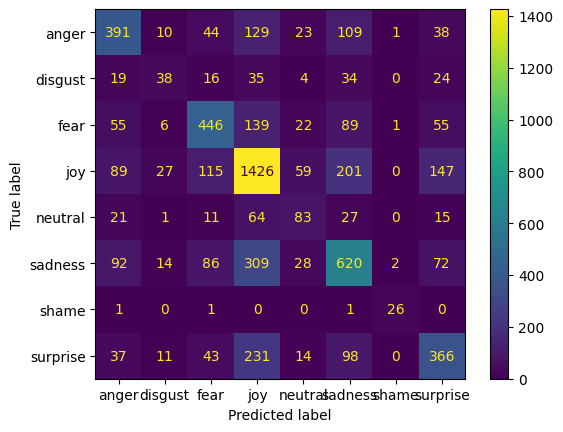

In [ ]:
cm_1_bow = confusion_matrix(y1_test, pred_1_bow)
disp_1_bow = ConfusionMatrixDisplay(confusion_matrix=cm_1_bow, display_labels=svm_1_bow.classes_)
disp_1_bow.plot()
plt.show()

#### TF-IDF

In [ ]:
tfidf_1 = TfidfVectorizer()
X1_train_tfidf = tfidf_1.fit_transform(X1_train)
X1_test_tfidf = tfidf_1.transform(X1_test)

svm_1_tfidf = LinearSVC()
svm_1_tfidf.fit(X1_train_tfidf, y1_train)
pred_1_tfidf = svm_1_tfidf.predict(X1_test_tfidf)

print("Accuracy: ", accuracy_score(y1_test, pred_1_tfidf))
print("Precision: ", precision_score(y1_test, pred_1_tfidf, average='weighted'))
print("Recall: ", recall_score(y1_test, pred_1_tfidf, average='weighted'))
print("F1 Score: ", f1_score(y1_test, pred_1_tfidf, average='weighted'))

Accuracy:  0.5809429607649192
Precision:  0.5734547207036207
Recall:  0.5809429607649192
F1 Score:  0.5728780983824435


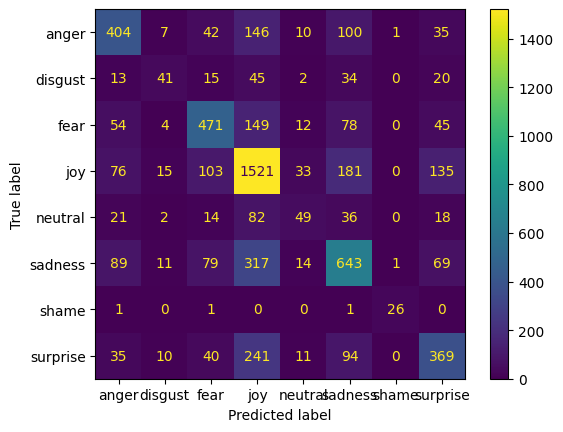

In [ ]:
cm_1_tfidf = confusion_matrix(y1_test, pred_1_tfidf)
disp_1_tfidf = ConfusionMatrixDisplay(confusion_matrix=cm_1_tfidf, display_labels=svm_1_tfidf.classes_)
disp_1_tfidf.plot()
plt.show()

### Dataset 2

In [ ]:
X_2 = dataset_2['sentence']
y_2 = dataset_2['emotion']

X2_train, X2_test, y2_train, y2_test = train_test_split(X_2, y_2, test_size=0.2, random_state=42, stratify=y_2)

#### Bag of Words

In [ ]:
bow_2 = CountVectorizer()
X2_train_bow = bow_2.fit_transform(X2_train)
X2_test_bow = bow_2.transform(X2_test)

svm_2_bow = LinearSVC()
svm_2_bow.fit(X2_train_bow, y2_train)
pred_2_bow = svm_2_bow.predict(X2_test_bow)

print("Accuracy: ", accuracy_score(y2_test, pred_2_bow))
print("Precision: ", precision_score(y2_test, pred_2_bow, average='weighted'))
print("Recall: ", recall_score(y2_test, pred_2_bow, average='weighted'))
print("F1 Score: ", f1_score(y2_test, pred_2_bow, average='weighted'))

Accuracy:  0.9008121947687812
Precision:  0.900387386154045
Recall:  0.9008121947687812
F1 Score:  0.9004835099860776


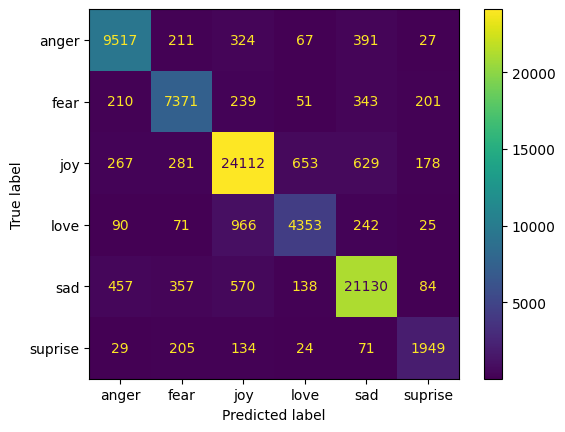

In [ ]:
cm_2_bow = confusion_matrix(y2_test, pred_2_bow)
disp_2_bow = ConfusionMatrixDisplay(confusion_matrix=cm_2_bow, display_labels=svm_2_bow.classes_)
disp_2_bow.plot()
plt.show()

#### TF-IDF

In [ ]:
tfidf_2 = TfidfVectorizer()
X2_train_tfidf = tfidf_2.fit_transform(X2_train)
X2_test_tfidf = tfidf_2.transform(X2_test)

svm_2_tfidf = LinearSVC()
svm_2_tfidf.fit(X2_train_tfidf, y2_train)
pred_2_tfidf = svm_2_tfidf.predict(X2_test_tfidf)

print("Accuracy: ", accuracy_score(y2_test, pred_2_tfidf))
print("Precision: ", precision_score(y2_test, pred_2_tfidf, average='weighted'))
print("Recall: ", recall_score(y2_test, pred_2_tfidf, average='weighted'))
print("F1 Score: ", f1_score(y2_test, pred_2_tfidf, average='weighted'))

Accuracy:  0.9053931312280332
Precision:  0.9047810983629326
Recall:  0.9053931312280332
F1 Score:  0.9048474894220883


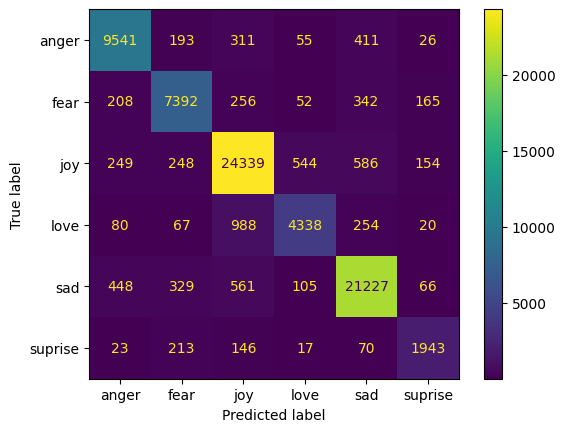

In [ ]:
cm_2_tfidf = confusion_matrix(y2_test, pred_2_tfidf)
disp_2_tfidf = ConfusionMatrixDisplay(confusion_matrix=cm_2_tfidf, display_labels=svm_2_tfidf.classes_)
disp_2_tfidf.plot()
plt.show()